In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\Aditi Mundra\OneDrive\Desktop\Butterfly Classification


In [4]:
from src.augmentation import create_training_generator

In [6]:
from src.data_loader import load_leeds_dataset
from src.preprocessing import (
    normalize_images,
    encode_labels,
    one_hot_encode,
    create_train_test_split
)

In [7]:
images, labels = load_leeds_dataset(
    "../data/raw/leedsbutterfly/images"
)

In [8]:
images = normalize_images(images)

encoded_labels, encoder = encode_labels(labels)

categorical_labels = one_hot_encode(
    encoded_labels
)

In [9]:
X_train, X_test, y_train, y_test = (
    create_train_test_split(
        images,
        categorical_labels
    )
)

In [10]:
train_datagen = create_training_generator()

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

In [11]:
batch_images, batch_labels = next(train_generator)

print(batch_images.shape)
print(batch_labels.shape)

(32, 224, 224, 3)
(32, 10)


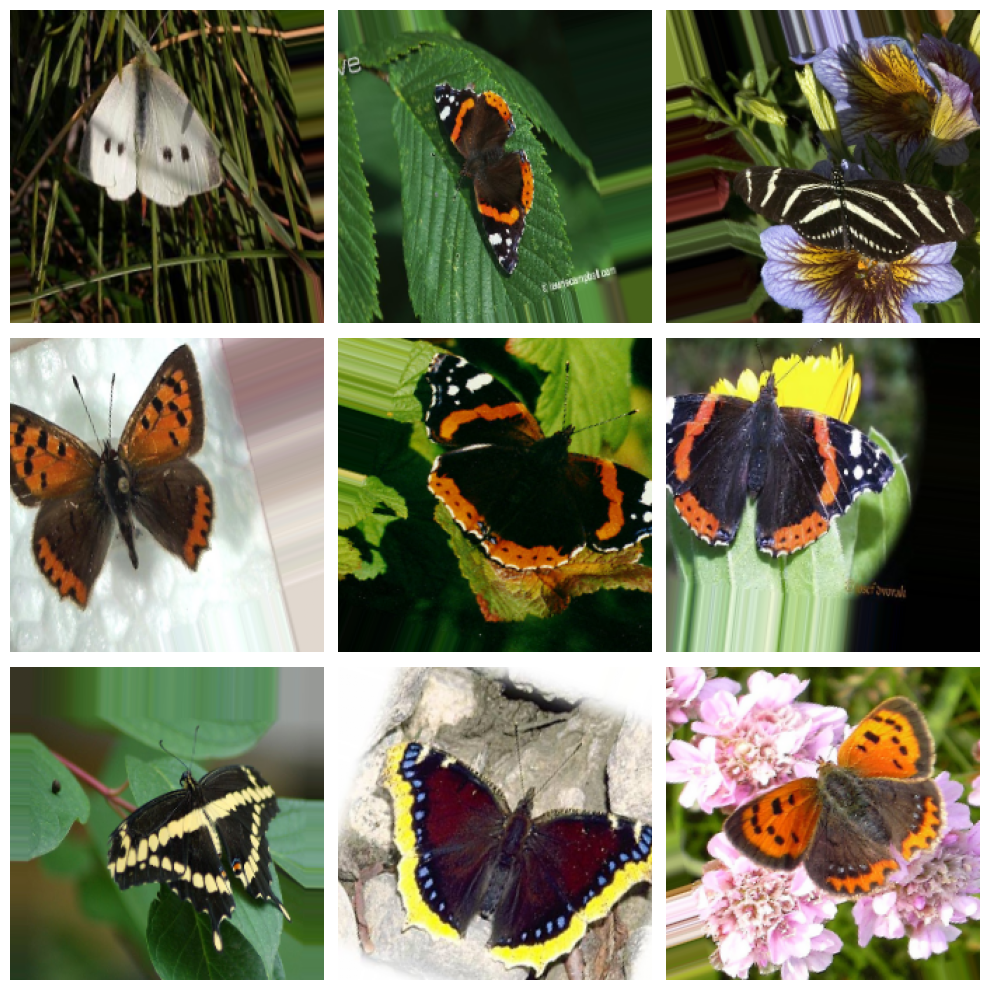

In [12]:
import matplotlib.pyplot as plt

batch_images, _ = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(batch_images[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

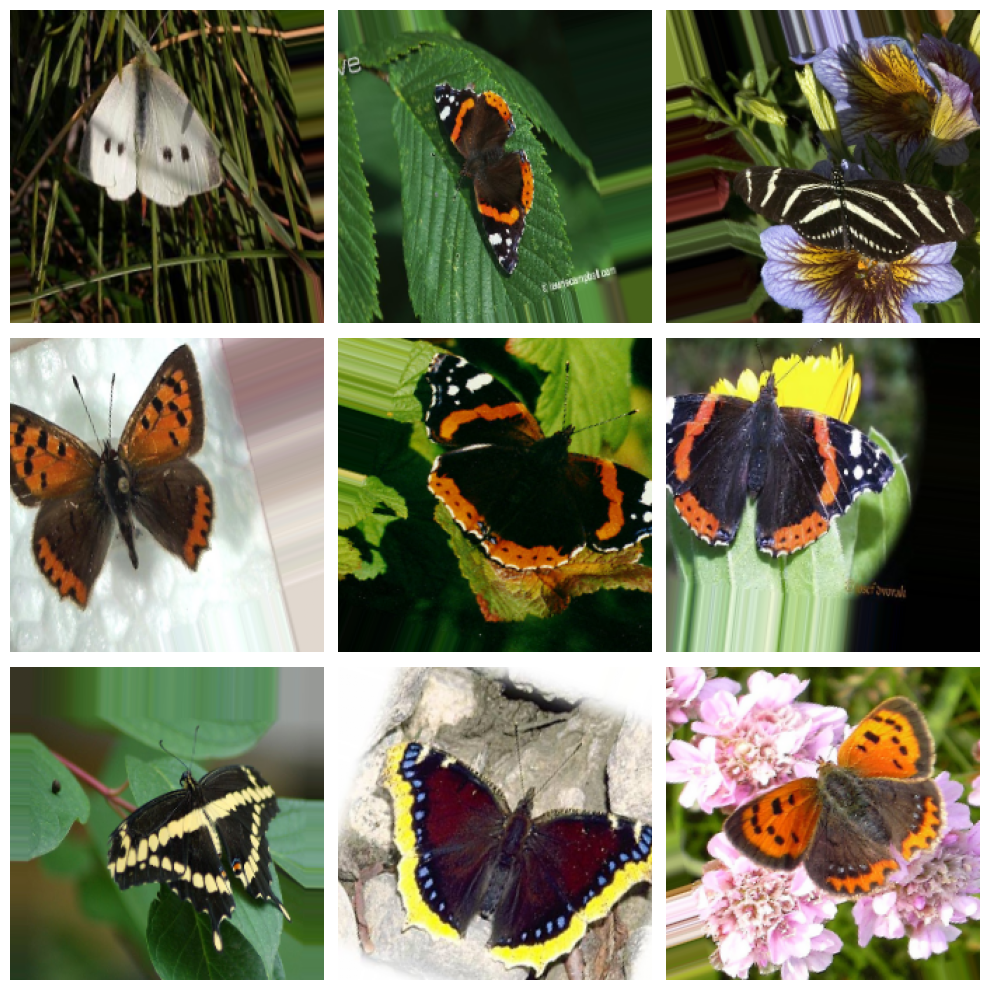

In [13]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(batch_images[i])

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/augmentation_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()